# Inspeção Inicial do Dataset

## Nota Técnica: Limitação de Memória no Kaggle

A primeira abordagem tentada foi carregar o dataset diretamente com `pd.read_csv()`:
```python
df = pd.read_csv('/kaggle/input/.../train.csv')
```

No entanto, com 40 milhões de registos, esta operação esgotou a memória RAM disponível no Kaggle
e o kernel morreu. Por essa razão, todas as células seguintes utilizam processamento em **chunks**
ou **Dask**, que permitem processar o dataset completo sem carregar tudo em memória de uma vez.

In [1]:
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/hugogrou/previso-de-cliques/train.csv
/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/sampleSubmission/sampleSubmission.csv
/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/test/test.csv
/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv


Feito por: Bernardo e Hugo

In [2]:
import pandas as pd
import numpy as np
from IPython.display import display
from collections import defaultdict

file_path = "/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv"
chunk_size = 1_000_000

total_rows = 0
null_counts = None
columns = None
dtypes = None

# Guardar TODOS os valores numéricos
numeric_data = defaultdict(list)

# Contagens completas das categóricas
categorical_counts = defaultdict(lambda: defaultdict(int))

print("A processar dataset completo...")

for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size)):
    
    total_rows += len(chunk)
    
    if i == 0:
        first_rows = chunk.head()
        columns = chunk.columns.tolist()
        dtypes = chunk.dtypes
    
    # Valores nulos globais
    if null_counts is None:
        null_counts = chunk.isnull().sum()
    else:
        null_counts += chunk.isnull().sum()
    
    # Separar tipos
    numeric_cols = chunk.select_dtypes(include=["int64", "float64"])
    categorical_cols = chunk.select_dtypes(include=["object"])
    
    # Guardar todos os valores numéricos (necessário para percentis exatos)
    for col in numeric_cols.columns:
        numeric_data[col].extend(numeric_cols[col].dropna().values)
    
    # Contagem completa categórica
    for col in categorical_cols.columns:
        counts = categorical_cols[col].value_counts()
        for key, value in counts.items():
            categorical_counts[col][key] += value

print("Processamento concluído.")


# RESULTADOS GERAIS


print("DIMENSÃO")
print((total_rows, len(columns)))

print("PRIMEIRAS 5 LINHAS")
display(first_rows)

print("TIPOS DE DADOS")
display(dtypes.to_frame("Tipo"))

print("VALORES NULOS")
display(null_counts.to_frame("Nulos"))

print("Total de valores nulos:", int(null_counts.sum()))


# ESTATÍSTICAS NUMÉRICAS COMPLETAS


print("ESTATÍSTICAS NUMÉRICAS ")

numeric_summary = {}

for col, values in numeric_data.items():
    arr = np.array(values)
    numeric_summary[col] = {
        "count": len(arr),
        "mean": np.mean(arr),
        "std": np.std(arr),
        "min": np.min(arr),
        "25%": np.percentile(arr, 25),
        "50%": np.percentile(arr, 50),
        "75%": np.percentile(arr, 75),
        "max": np.max(arr)
    }

numeric_summary_df = pd.DataFrame(numeric_summary).T
display(numeric_summary_df)


# ESTATÍSTICAS CATEGÓRICAS COMPLETAS


print("ESTATÍSTICAS CATEGÓRICAS ")

categorical_summary = {}

for col, value_dict in categorical_counts.items():
    
    total = sum(value_dict.values())
    unique = len(value_dict)
    top = max(value_dict, key=value_dict.get)
    freq = value_dict[top]
    
    categorical_summary[col] = {
        "count": total,
        "unique": unique,
        "top": top,
        "freq": freq
    }

categorical_summary_df = pd.DataFrame(categorical_summary).T
display(categorical_summary_df)


A processar dataset completo...
Processamento concluído.
DIMENSÃO
(40428967, 24)
PRIMEIRAS 5 LINHAS


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,1.000009e+18,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,2,15706,320,50,1722,0,35,-1,79
1,1.000017e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
2,1.000037e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
3,1.000064e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15706,320,50,1722,0,35,100084,79
4,1.000068e+19,0,14102100,1005,1,fe8cc448,9166c161,0569f928,ecad2386,7801e8d9,...,1,0,18993,320,50,2161,0,35,-1,157


TIPOS DE DADOS


,Tipo
id,float64
click,int64
hour,int64
C1,int64
banner_pos,int64
site_id,object
site_domain,object
site_category,object
app_id,object
app_domain,object


VALORES NULOS


,Nulos
id,0
click,0
hour,0
C1,0
banner_pos,0
site_id,0
site_domain,0
site_category,0
app_id,0
app_domain,0


Total de valores nulos: 0
ESTATÍSTICAS NUMÉRICAS 


,count,mean,std,min,25%,50%,75%,max
id,40428967.0,9.223017e+18,5.325443e+18,5.211594e+11,4.611181e+18,9.223224e+18,1.383561e+19,1.844674e+19
click,40428967.0,1.698056e-01,3.754619e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
hour,40428967.0,1.410256e+07,2.966837e+02,1.410210e+07,1.410230e+07,1.410260e+07,1.410281e+07,1.410302e+07
C1,40428967.0,1.004968e+03,1.094586e+00,1.001000e+03,1.005000e+03,1.005000e+03,1.005000e+03,1.012000e+03
banner_pos,40428967.0,2.880146e-01,5.063820e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,7.000000e+00
device_type,40428967.0,1.015305e+00,5.274336e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.000000e+00
device_conn_type,40428967.0,3.313150e-01,8.547935e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00
C14,40428967.0,1.884181e+04,4.959457e+03,3.750000e+02,1.692000e+04,2.034600e+04,2.189400e+04,2.405200e+04
C15,40428967.0,3.188831e+02,2.127250e+01,1.200000e+02,3.200000e+02,3.200000e+02,3.200000e+02,1.024000e+03
C16,40428967.0,6.010201e+01,4.729538e+01,2.000000e+01,5.000000e+01,5.000000e+01,5.000000e+01,1.024000e+03


ESTATÍSTICAS CATEGÓRICAS 


,count,unique,top,freq
site_id,40428967,4737,85f751fd,14596137
site_domain,40428967,7745,c4e18dd6,15131739
site_category,40428967,26,50e219e0,16537234
app_id,40428967,8552,ecad2386,25832830
app_domain,40428967,559,7801e8d9,27237087
app_category,40428967,36,07d7df22,26165592
device_id,40428967,2686408,a99f214a,33358308
device_ip,40428967,6729486,6b9769f2,208701
device_model,40428967,8251,8a4875bd,2455470


Esta célula realiza uma inspeção inicial completa do dataset sem o carregar todo em memória, processando-o em blocos de 1 milhão de linhas de cada vez. No final, apresenta um resumo completo com dimensões, primeiras linhas, estatísticas numéricas (média, percentis, etc.) e estatísticas categóricas (valores únicos, mais frequentes, etc.).

Feito por: Bernardo e Hugo

In [3]:
import pandas as pd
import numpy as np

# CONFIGURAÇÃO
file_path = "/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv"
chunk_size = 100000

# Tipos esperados (ajustados ao Avazu)
expected_types = {
    "id":               "string",
    "click":            "int64",
    "hour":             "string",
    "C1":               "int64",
    "banner_pos":       "int64",
    "site_id":          "string",
    "site_domain":      "string",
    "site_category":    "string",
    "app_id":           "string",
    "app_domain":       "string",
    "app_category":     "string",
    "device_id":        "string",
    "device_ip":        "string",
    "device_model":     "string",
    "device_type":      "int64",
    "device_conn_type": "int64",
    "C14":              "int64",
    "C15":              "int64",
    "C16":              "int64",
    "C17":              "int64",
    "C18":              "int64",
    "C19":              "int64",
    "C20":              "int64",
    "C21":              "int64"
}

# VARIÁVEIS DE CONTROLO
total_rows = 0
invalid_counts = {col: 0 for col in expected_types}
type_mismatches = set()

# PROCESSAMENTO EM CHUNKS
for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    
    total_rows += len(chunk)
    
    for col, expected_type in expected_types.items():
        
        if col not in chunk.columns:
            print(f"Coluna {col} não existe no dataset.")
            continue
        
        actual_type = str(chunk[col].dtype)
        
        # Verificar tipo incorreto
        if expected_type == "string":
            if actual_type not in ["object", "string"]:
                type_mismatches.add((col, actual_type, expected_type))
        else:
            if actual_type != expected_type:
                type_mismatches.add((col, actual_type, expected_type))
        
        # Converter automaticamente
        try:
            if expected_type == "int64":
                chunk[col] = pd.to_numeric(chunk[col], errors="coerce")
            
            elif expected_type == "string":
                chunk[col] = chunk[col].astype("string")
        
        except Exception as e:
            print(f"Erro ao converter {col}: {e}")
        
        # Contar valores inválidos
        invalid_counts[col] += chunk[col].isnull().sum()

# RESULTADOS FINAIS
print("\n VERIFICAÇÃO DE INTEGRIDADE \n")
print(f"Total de linhas processadas: {total_rows}\n")

print("Tipos incorretos encontrados:")
if type_mismatches:
    for col, actual, expected in type_mismatches:
        print(f" - {col}: atual={actual} | esperado={expected}")
else:
    print(" Nenhum problema de tipo encontrado.")

print("\nValores inválidos após conversão:")
for col, count in invalid_counts.items():
    print(f" - {col}: {count} valores inválidos")

print("\nVerificação concluída.")


 VERIFICAÇÃO DE INTEGRIDADE 

Total de linhas processadas: 40428967

Tipos incorretos encontrados:
 - id: atual=float64 | esperado=string
 - id: atual=int64 | esperado=string
 - id: atual=uint64 | esperado=string
 - hour: atual=int64 | esperado=string

Valores inválidos após conversão:
 - id: 0 valores inválidos
 - click: 0 valores inválidos
 - hour: 0 valores inválidos
 - C1: 0 valores inválidos
 - banner_pos: 0 valores inválidos
 - site_id: 0 valores inválidos
 - site_domain: 0 valores inválidos
 - site_category: 0 valores inválidos
 - app_id: 0 valores inválidos
 - app_domain: 0 valores inválidos
 - app_category: 0 valores inválidos
 - device_id: 0 valores inválidos
 - device_ip: 0 valores inválidos
 - device_model: 0 valores inválidos
 - device_type: 0 valores inválidos
 - device_conn_type: 0 valores inválidos
 - C14: 0 valores inválidos
 - C15: 0 valores inválidos
 - C16: 0 valores inválidos
 - C17: 0 valores inválidos
 - C18: 0 valores inválidos
 - C19: 0 valores inválidos
 - C2

Esta célula verifica a integridade dos tipos de dados de todas as 24 colunas do dataset Avazu. Para cada coluna, compara o tipo real com o esperado, tenta corrigi-lo automaticamente e conta quantos valores ficaram inválidos após conversão, apresentando no final um relatório completo com os problemas encontrados.

Feito por: Hugo e Bernardo

In [4]:
import dask.dataframe as dd
import pandas as pd

# Caminho para o dataset
file_path = "/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv"

# Ler o dataset
df_dask = dd.read_csv(file_path, dtype={'id': 'float64'})

# Colunas anonimizadas que podem ter o valor oculto '-1'
colunas_para_verificar = ['C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21']

# Calcular o total de linhas para fazer a percentagem
linhas_totais = df_dask.shape[0].compute()

print("A procurar valores em falta mascarados como '-1'...")

resultados = []
for col in colunas_para_verificar:
    # Contar quantos valores -1 existem na coluna
    contagem_escondidos = (df_dask[col] == -1).sum().compute()
    percentagem = (contagem_escondidos / linhas_totais) * 100
    
    resultados.append({
        'Coluna': col, 
        'Valores -1 (Missing)': contagem_escondidos, 
        'Percentagem (%)': round(percentagem, 2)
    })

# Apresentar a tabela final ordenada
df_resultados = pd.DataFrame(resultados)
display(df_resultados.sort_values(by='Percentagem (%)', ascending=False))

A procurar valores em falta mascarados como '-1'...


,Coluna,Valores -1 (Missing),Percentagem (%)
6,C20,18937918,46.84
0,C14,0,0.00
2,C16,0,0.00
1,C15,0,0.00
3,C17,0,0.00
4,C18,0,0.00
5,C19,0,0.00
7,C21,0,0.00


Esta célula usa Dask para percorrer os 40M de registos e detetar valores `-1` nas colunas anónimas (C14–C21), que no dataset Avazu representam dados em falta mascarados, apresentando no final a contagem e percentagem de ocorrências por coluna.

Feito por: Bernardo e Hugo

/tmp/ipykernel_17/2897455366.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_10.index, y=top_10.values, palette='mako')


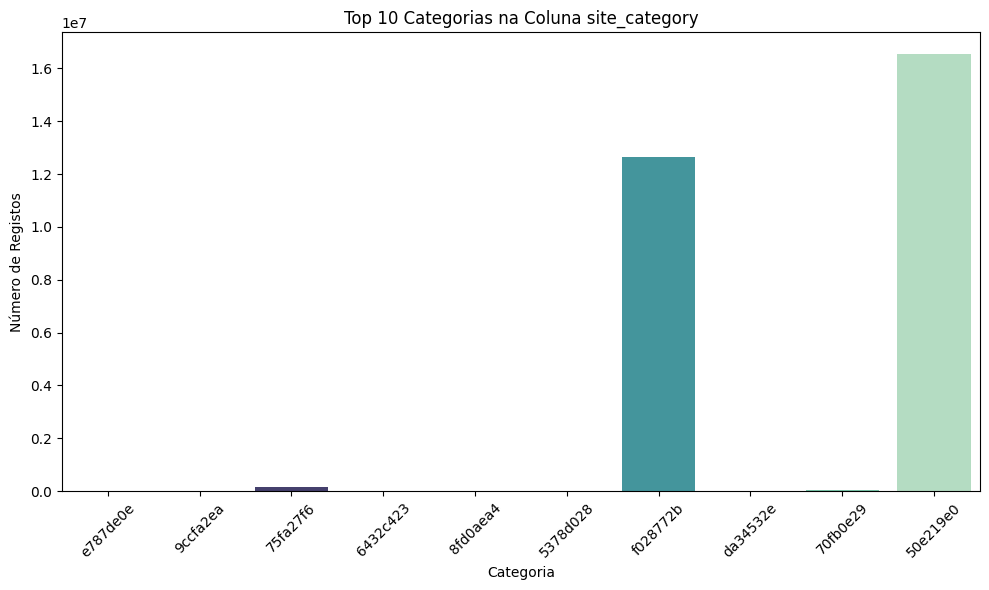

/tmp/ipykernel_17/2897455366.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_10.index, y=top_10.values, palette='mako')


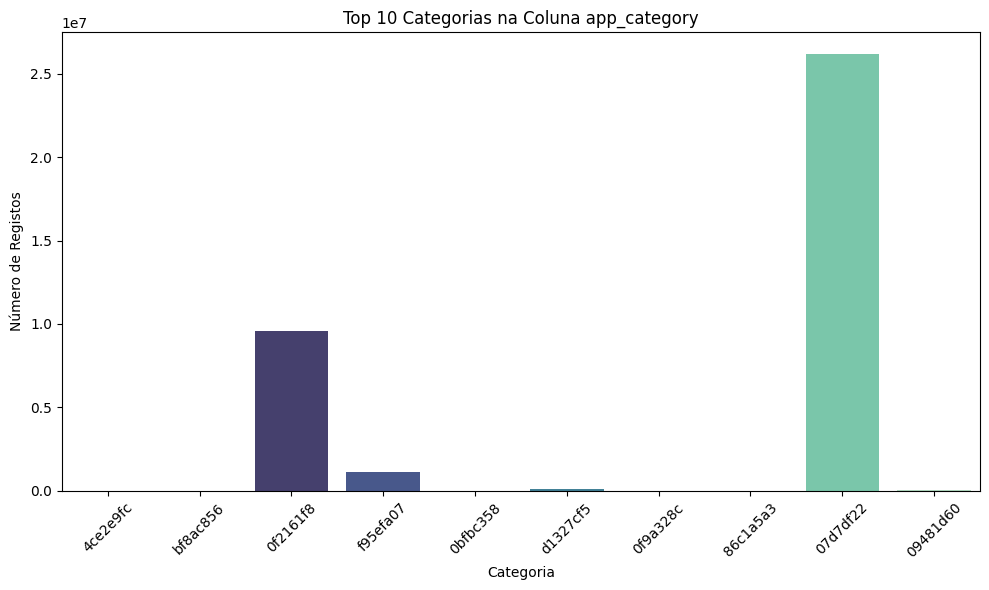

/tmp/ipykernel_17/2897455366.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_10.index, y=top_10.values, palette='mako')


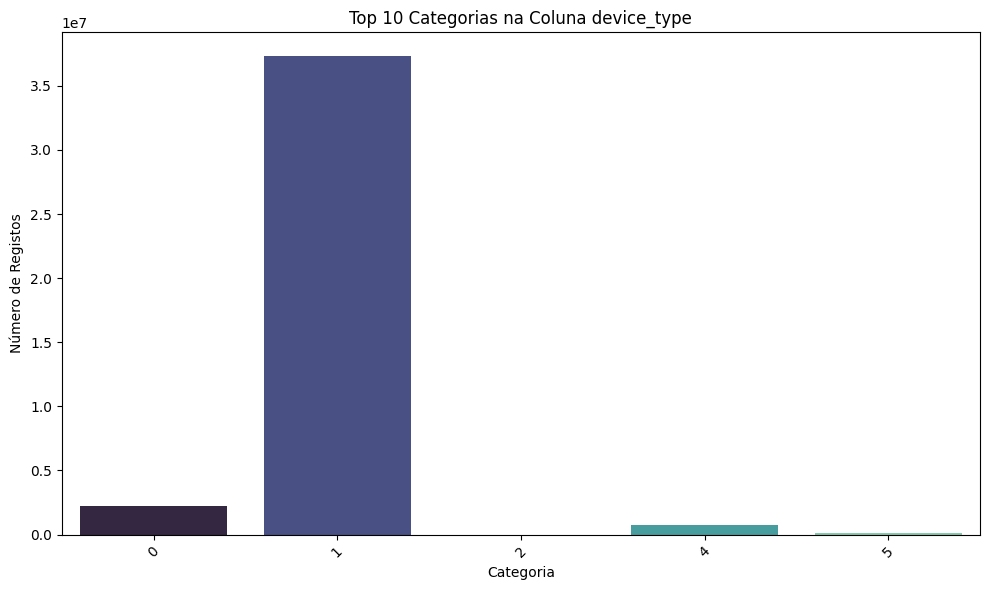

/tmp/ipykernel_17/2897455366.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_10.index, y=top_10.values, palette='mako')


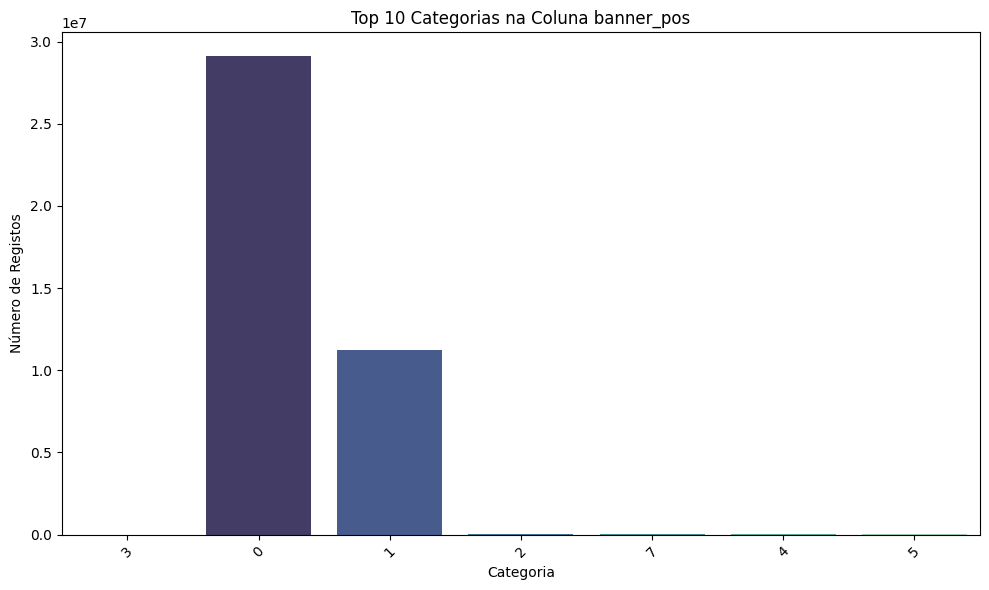

/tmp/ipykernel_17/2897455366.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_10.index, y=top_10.values, palette='mako')


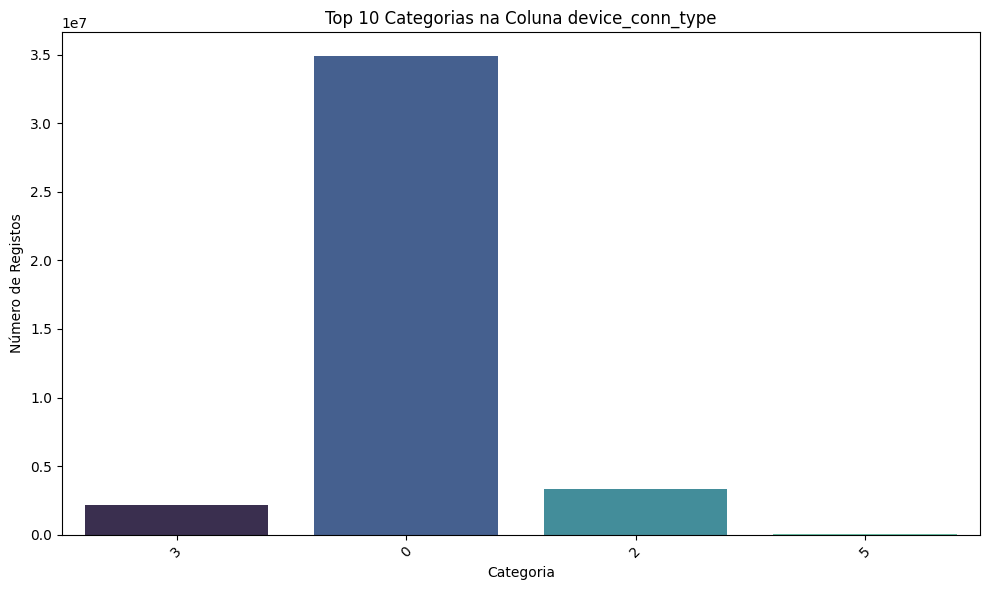

In [5]:
import dask.dataframe as dd
import matplotlib.pyplot as plt
import seaborn as sns

# Caminho para o dataset
file_path = "/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv"
df_dask = dd.read_csv(file_path, dtype={'id': 'float64'})

# Colunas mais relevantes para o Objetivo 2
colunas_alvo = ['site_category', 'app_category', 'device_type', 'banner_pos', 'device_conn_type']

for coluna_alvo in colunas_alvo:

    # Contar as categorias e calcular no Dask
    contagem_categorias = df_dask[coluna_alvo].value_counts().compute()

    # Converter o índice para string para podermos renomear o '-1'
    contagem_categorias.index = contagem_categorias.index.astype(str)

    # Renomear a categoria '-1' para 'Desconhecido' (caso ela exista)
    if '-1' in contagem_categorias.index:
        contagem_categorias = contagem_categorias.rename({'-1': 'Desconhecido'})

    # Fazer o gráfico apenas com as 10 categorias mais frequentes
    top_10 = contagem_categorias.head(10)

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=top_10.index, y=top_10.values, palette='mako')
    plt.title(f'Top 10 Categorias na Coluna {coluna_alvo}')
    plt.xlabel('Categoria')
    plt.ylabel('Número de Registos')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Esta célula analisa a distribuição das 5 variáveis mais relevantes para o Objetivo 2 (`site_category`, `app_category`, `device_type`, `banner_pos`, `device_conn_type`), gerando para cada uma um gráfico com as 10 categorias mais frequentes, permitindo identificar quais os valores dominantes em cada variável antes da modelagem.

Feito por: Bernardo e Hugo

/tmp/ipykernel_17/2003453377.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=target_percentages.index, y=target_percentages.values, palette='viridis')


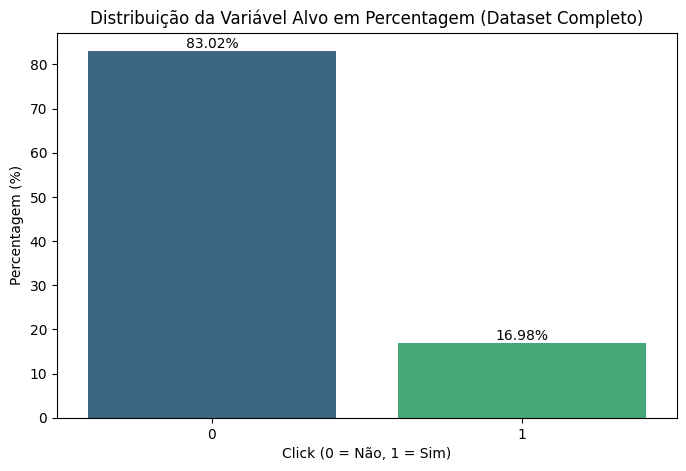

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Caminho para o dataset
file_path = "/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv"
chunksize = 10**6  # Definir o tamanho do chunk para não esgotar a RAM

# Inicializar série para guardar as contagens totais
target_counts = pd.Series(dtype=int)

# Contar valores iterando por todo o dataset
for chunk in pd.read_csv(file_path, chunksize=chunksize, usecols=['click']):
    target_counts = target_counts.add(chunk['click'].value_counts(), fill_value=0)

# Calcular o total de registos e as percentagens
total_registos = target_counts.sum()
target_percentages = (target_counts / total_registos) * 100

# Criar o gráfico usando as percentagens
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=target_percentages.index, y=target_percentages.values, palette='viridis')
plt.title('Distribuição da Variável Alvo em Percentagem (Dataset Completo)')
plt.xlabel('Click (0 = Não, 1 = Sim)')
plt.ylabel('Percentagem (%)')

# Adicionar os valores exatos em percentagem no topo das barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

Esta célula analisa o desequilíbrio da variável alvo `click`, processando os 40M de registos em chunks para calcular a percentagem de cliques (1) e não-cliques (0), visualizando o resultado num gráfico de barras — o que é essencial para justificar o uso das métricas adequadas a classes desbalanceadas definidas no Objetivo 4.

Feito por: Bernardo e Hugo

Iniciando processamento por chunks (Dataset Inteiro)...
Processamento concluído. Gerando visualizações...


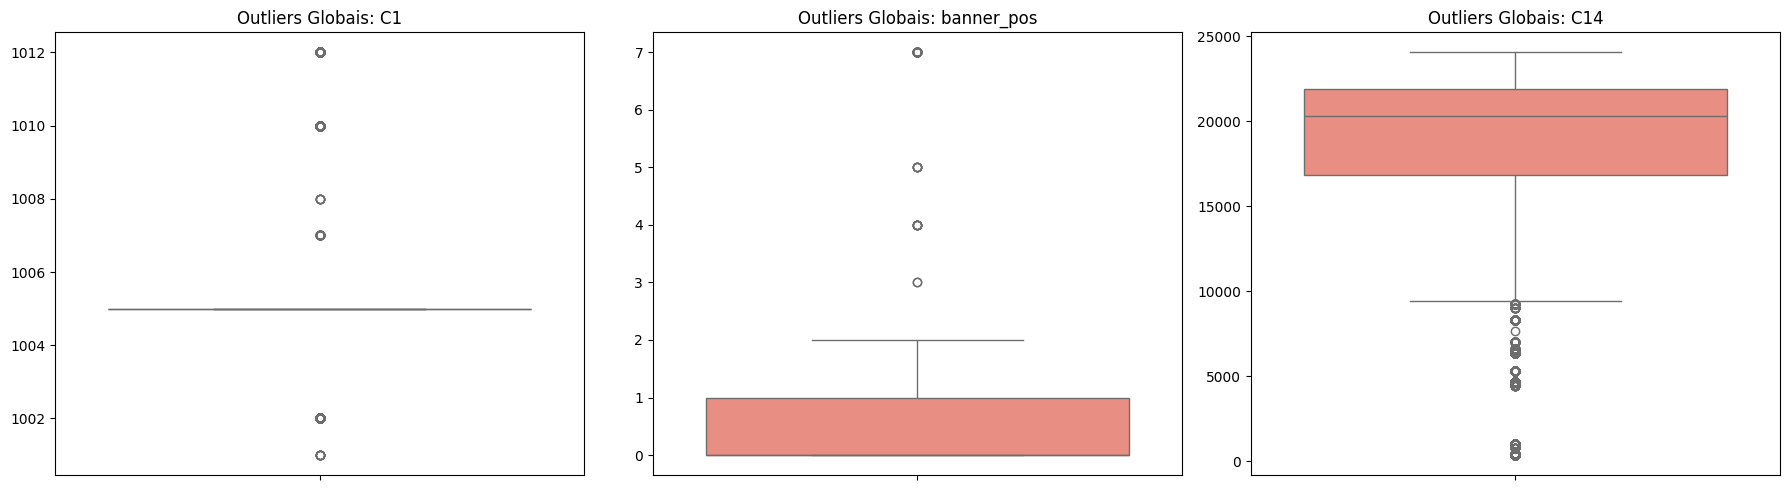

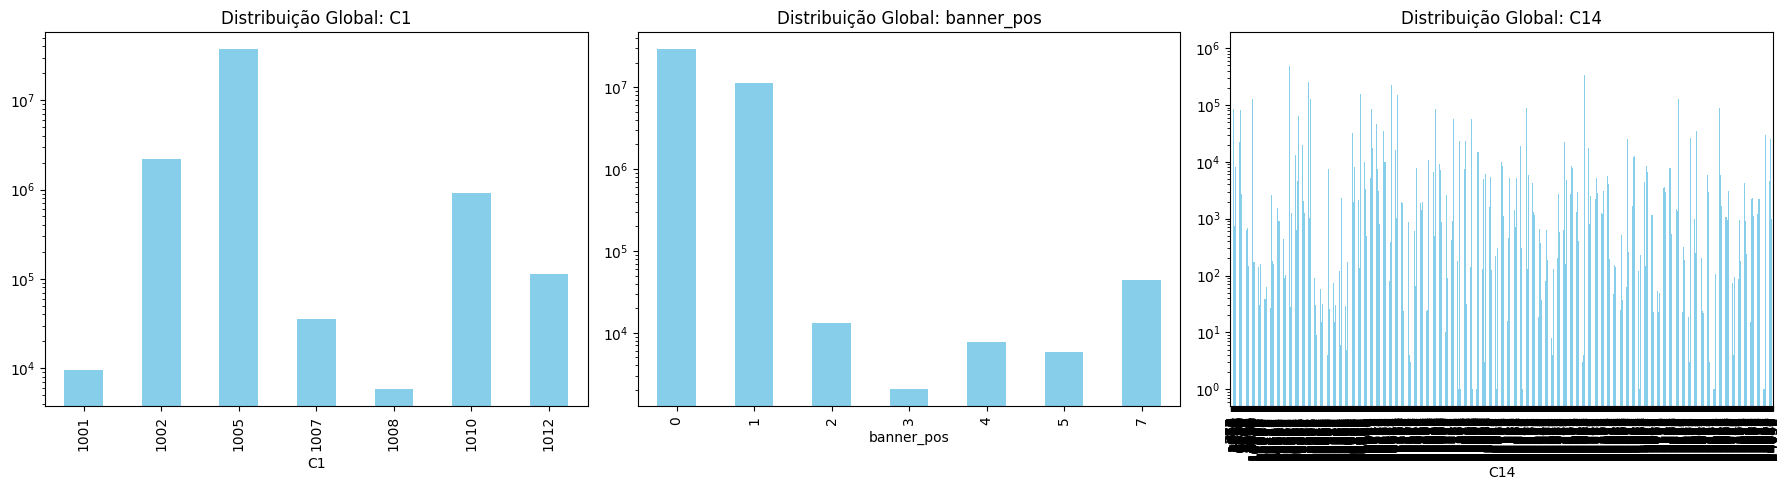

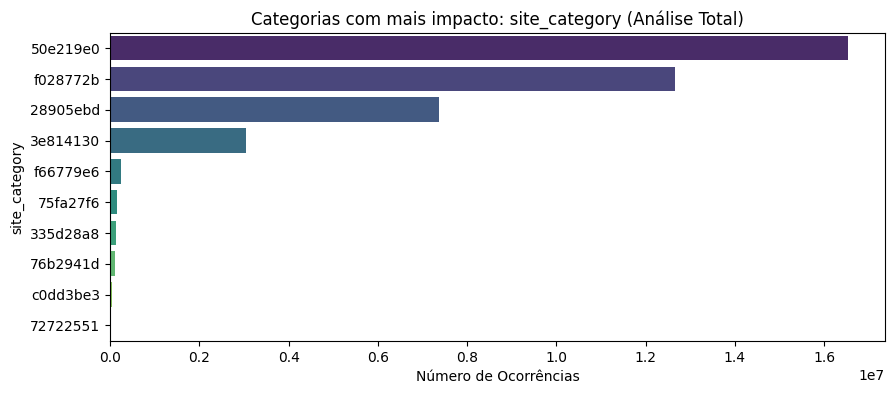

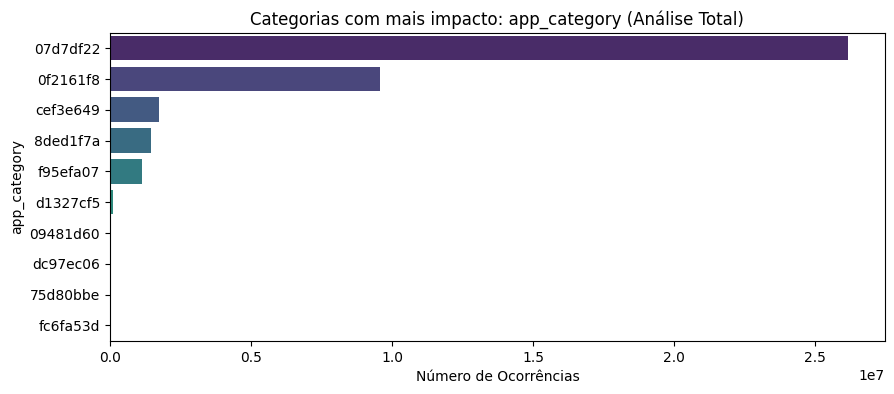

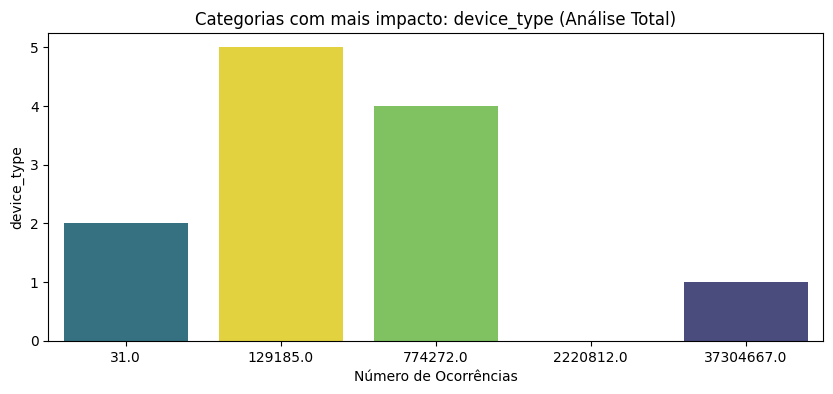

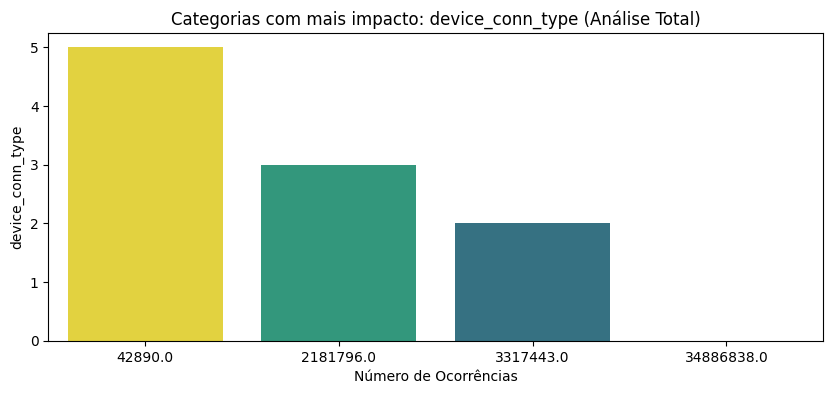

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurações Iniciais
file_path = "/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv"
chunk_size = 2_000_000
cols_numericas = ['C1', 'banner_pos', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'device_type', 'device_conn_type']
cols_categoricas = ['site_category', 'app_category', 'device_type', 'device_conn_type']

# Dicionários para armazenar as agregações
counts_num = {col: pd.Series(dtype='int64') for col in cols_numericas}
counts_cat = {col: pd.Series(dtype='int64') for col in cols_categoricas}

print("Iniciando processamento por chunks (Dataset Inteiro)...")

# 2. Processamento em Loop
for chunk in pd.read_csv(file_path, chunksize=chunk_size, usecols=cols_numericas + cols_categoricas):
    for col in cols_numericas:
        counts_num[col] = counts_num[col].add(chunk[col].value_counts(), fill_value=0)
    
    for col in cols_categoricas:
        counts_cat[col] = counts_cat[col].add(chunk[col].value_counts(), fill_value=0)

print("Processamento concluído. Gerando visualizações...")

# ---------------------------------------------------------
# 3. Visualização de Outliers (Boxplots)
# ---------------------------------------------------------
plt.figure(figsize=(18, 5))
for i, col in enumerate(['C1', 'banner_pos', 'C14']):
    plt.subplot(1, 3, i+1)
    v = counts_num[col].index.values
    w = counts_num[col].values
    sns.boxplot(y=np.repeat(v, w.astype(int) // 1000), color='salmon')
    plt.title(f'Outliers Globais: {col}')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Histogramas (Distribuição Global)
# ---------------------------------------------------------
plt.figure(figsize=(18, 5))
for i, col in enumerate(['C1', 'banner_pos', 'C14']):
    plt.subplot(1, 3, i+1)
    counts_num[col].sort_index().plot(kind='bar', color='skyblue')
    plt.title(f'Distribuição Global: {col}')
    plt.yscale('log')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. Frequência Categórica (Deep EDA)
# ---------------------------------------------------------
for col in cols_categoricas:
    plt.figure(figsize=(10, 4))
    top_10 = counts_cat[col].sort_values(ascending=False).head(10)
    sns.barplot(x=top_10.values, y=top_10.index, hue=top_10.index, palette='viridis', legend=False)
    plt.title(f'Categorias com mais impacto: {col} (Análise Total)')
    plt.xlabel('Número de Ocorrências')
    plt.show()

Esta célula realiza uma análise exploratória profunda das variáveis mais relevantes para o Objetivo 2. Para as variáveis numéricas gera boxplots para identificar outliers e histogramas com escala logarítmica para visualizar a distribuição completa, enquanto para as categóricas apresenta as 10 categorias mais frequentes em gráficos de barras — cobrindo assim todas as variáveis candidatas a figurar no top 5 de maior impacto no CTR.

Feito por: Hugo e Bernardo


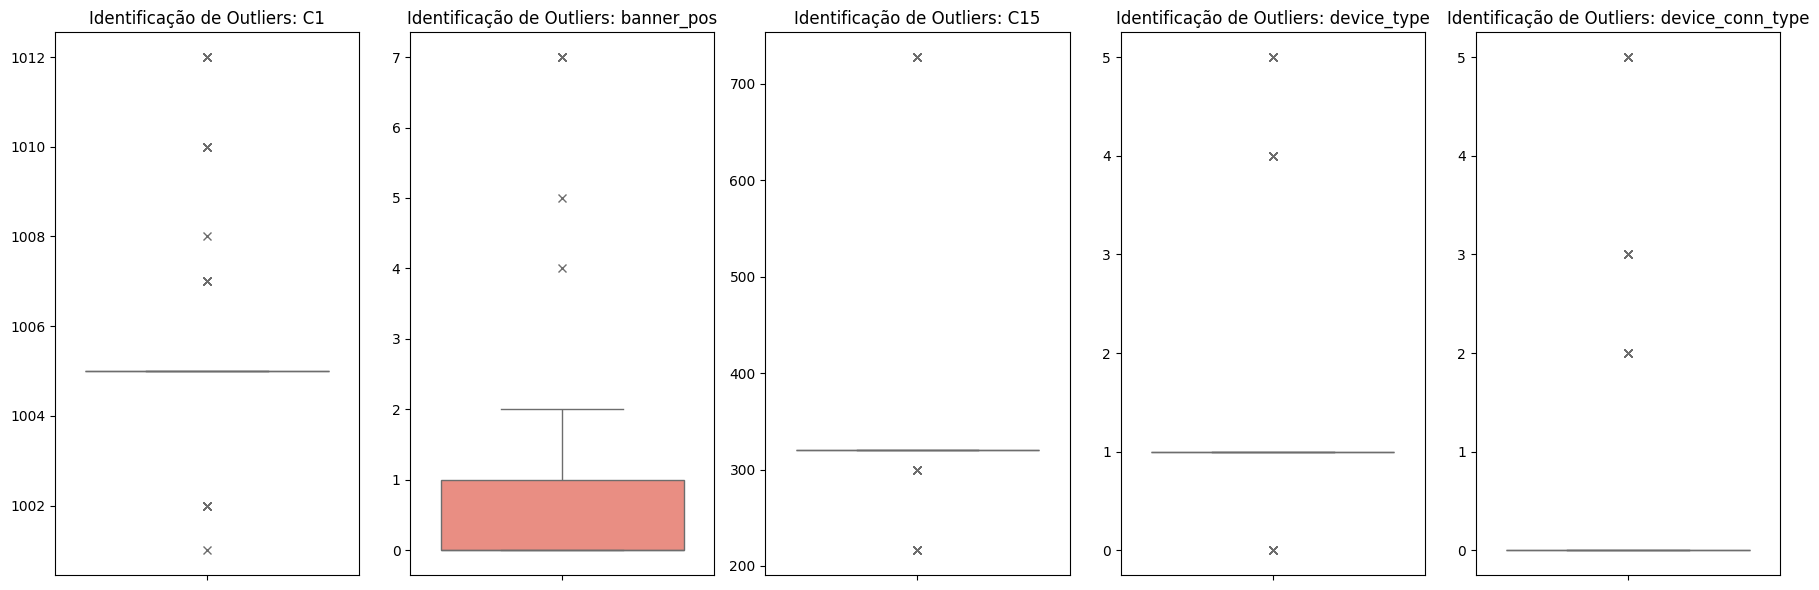

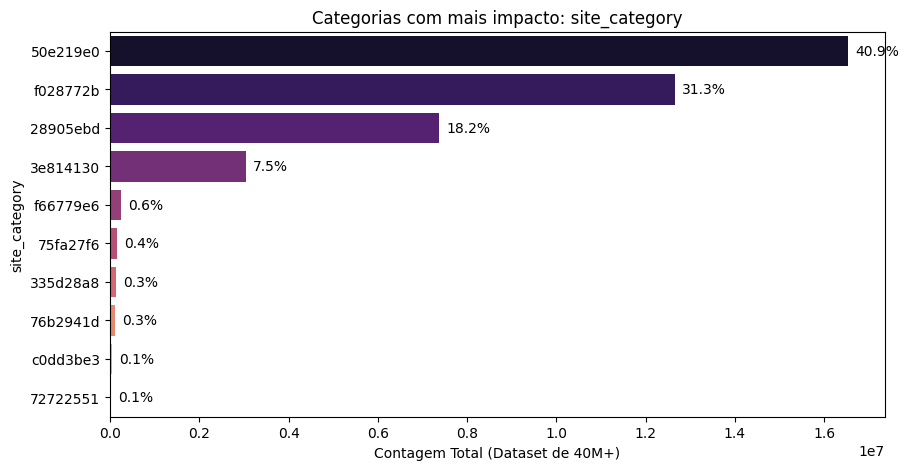

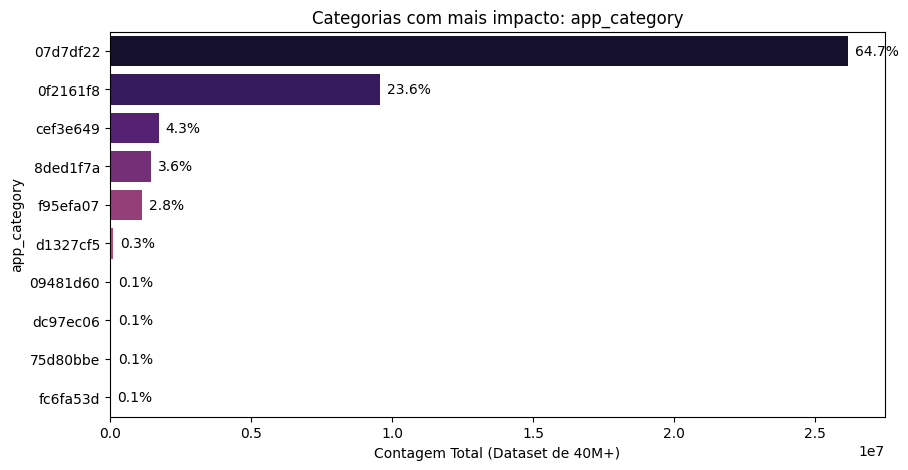

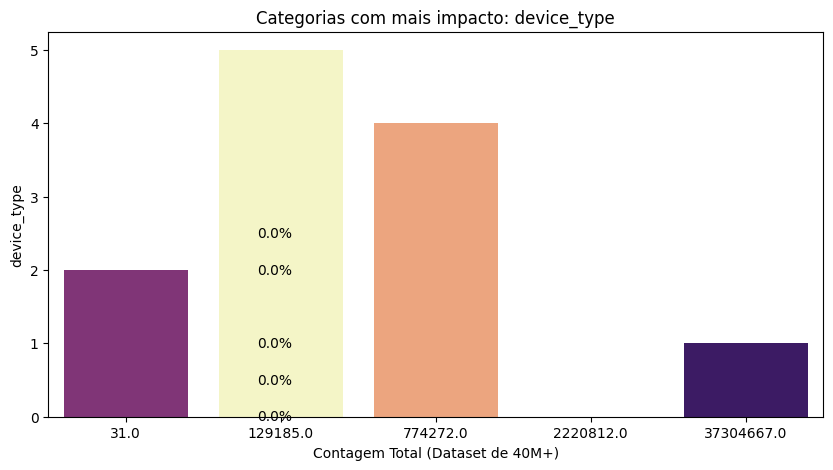

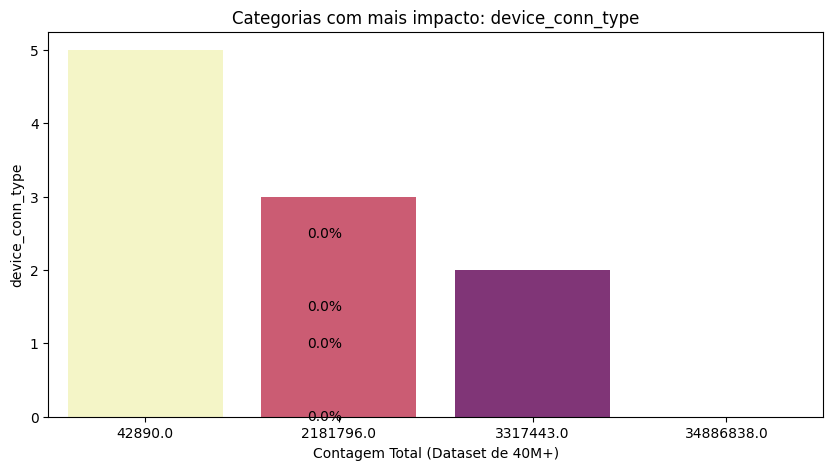

In [8]:
plt.figure(figsize=(18, 6))
cols_para_boxplot = ['C1', 'banner_pos', 'C15', 'device_type', 'device_conn_type']

for i, col in enumerate(cols_para_boxplot):
    plt.subplot(1, 5, i+1)
    
    # Criar amostra proporcional para o boxplot
    v = counts_num[col].index.values
    w = counts_num[col].values
    amostra = np.repeat(v, w.astype(int) // 5000)
    
    # Desenhar o boxplot com destaque nos outliers
    sns.boxplot(y=amostra, color='salmon', flierprops={"marker": "x", "markerfacecolor": "red"})
    plt.title(f'Identificação de Outliers: {col}')

plt.tight_layout()
plt.show()

# --- Frequência Categórica com Percentagens ---
for col in cols_categoricas:
    plt.figure(figsize=(10, 5))
    top_10 = counts_cat[col].sort_values(ascending=False).head(10)
    
    ax = sns.barplot(x=top_10.values, y=top_10.index, hue=top_10.index, palette='magma', legend=False)
    
    # Adicionar labels de percentagem nas barras
    total_col = counts_cat[col].sum()
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_width()/total_col)
        ax.annotate(percentage, (p.get_width(), p.get_y() + p.get_height() / 2), 
                    xytext=(5, 0), textcoords='offset points', va='center')
    
    plt.title(f'Categorias com mais impacto: {col}')
    plt.xlabel('Contagem Total (Dataset de 40M+)')
    plt.show()

Esta célula gera duas visualizações complementares: primeiro, boxplots para as 5 variáveis mais relevantes (`C1`, `banner_pos`, `C15`, `device_type`, `device_conn_type`) usando amostras proporcionais para identificar outliers, e depois gráficos de barras horizontais com percentagens para as variáveis categóricas, permitindo perceber quais as categorias dominantes em cada variável e o seu peso relativo no dataset.

Feito por: Hugo e Bernardo 

In [9]:
import numpy as np
import pandas as pd

def calcular_estatisticas_completas(dicionario_counts):
    resultados = []
    
    print(f"{'Coluna':<15} | {'Total Outliers':<15} | {'% do Total':<10}")
    print("-" * 45)
    
    for col, counts in dicionario_counts.items():
        valores = counts.index.values
        pesos = counts.values.astype(int)
        
        # Total de registos na coluna
        total_obs = pesos.sum()
        
        # Usar np.maximum para garantir que nenhum peso fica a 0
        pesos_reduzidos = np.maximum(pesos // 1000, 1)
        amostra_estatistica = np.repeat(valores, pesos_reduzidos)
        
        q1 = np.percentile(amostra_estatistica, 25)
        q3 = np.percentile(amostra_estatistica, 75)
        iqr = q3 - q1
        
        # Definir limites
        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr
        
        # Identificar Outliers no dicionário completo
        outliers_mask = (counts.index < limite_inferior) | (counts.index > limite_superior)
        total_outliers = counts[outliers_mask].sum()
        percentagem = (total_outliers / total_obs) * 100
        
        resultados.append({
            'Coluna': col,
            'Outliers': int(total_outliers),
            'Percentagem': percentagem,
            'Limite Inf': limite_inferior,
            'Limite Sup': limite_superior
        })
        
        print(f"{col:<15} | {int(total_outliers):<15,} | {percentagem:.2f}%")
    
    return pd.DataFrame(resultados)

# Executar a função
df_outliers = calcular_estatisticas_completas(counts_num)

Coluna          | Total Outliers  | % do Total
---------------------------------------------
C1              | 3,288,335       | 8.13%
banner_pos      | 59,094          | 0.15%
C14             | 3,334,194       | 8.25%
C15             | 2,720,008       | 6.73%
C16             | 2,292,413       | 5.67%
C17             | 3,426,891       | 8.48%
C18             | 0               | 0.00%
C19             | 7,280,702       | 18.01%
C20             | 0               | 0.00%
C21             | 5,765,448       | 14.26%
device_type     | 3,124,300       | 7.73%
device_conn_type | 5,542,129       | 13.71%


Esta célula calcula os outliers para todas as colunas numéricas usando o método IQR, sem carregar os dados todos em memória. Para cada coluna, constrói uma amostra proporcional a partir das contagens já calculadas anteriormente, determina os limites inferior e superior, e conta quantos registos ficam fora desses limites, apresentando no final uma tabela com o total de outliers e a sua percentagem por coluna.

Feito por: Bernardo e Hugo

A iniciar nova passagem em chunks para Bivariada e Correlação...


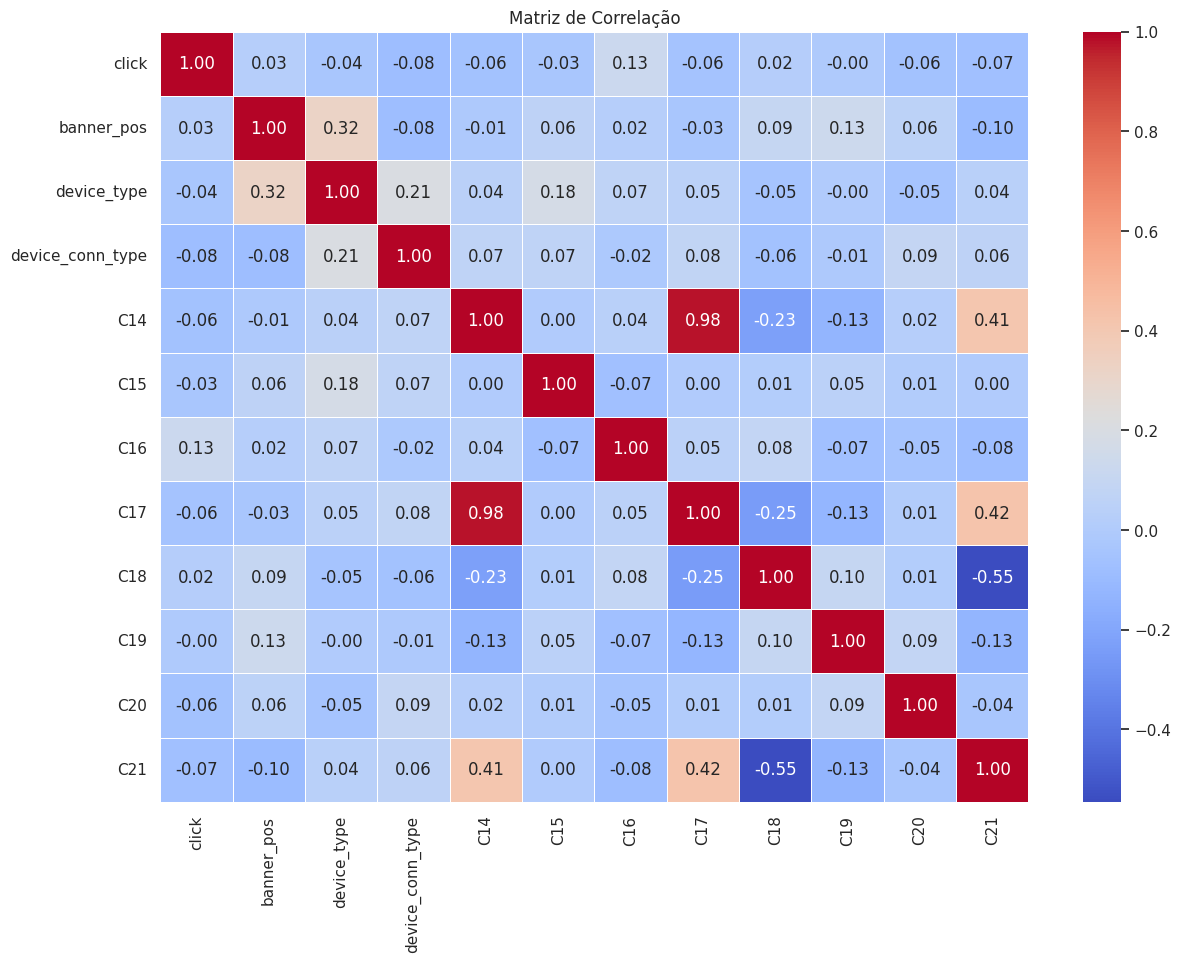


Correlações com a variável alvo ('click'):
 - C16: 0.1300
 - device_conn_type: -0.0834
 - C21: -0.0700
 - C14: -0.0602
 - C20: -0.0575
 - C17: -0.0557
 - device_type: -0.0378
 - C15: -0.0325
 - banner_pos: 0.0259
 - C18: 0.0216
 - C19: -0.0040


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from collections import defaultdict

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

file_path = "/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv"
chunk_size = 1_000_000

# Variáveis para a Matriz de Correlação (apenas numéricas/ordinais)
cols_to_correlate = ['click', 'banner_pos', 'device_type', 'device_conn_type', 
                     'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21']
n_cols = len(cols_to_correlate)

# Acumuladores Matemáticos para a Correlação de Pearson Incremental
n_total_corr = 0
sum_x = np.zeros(n_cols)
sum_sq_x = np.zeros(n_cols)
sum_xy = np.zeros((n_cols, n_cols))

# Acumuladores para a Análise Bivariada (Taxa de Cliques - CTR)
hour_stats = defaultdict(lambda: {'clicks': 0, 'impressions': 0})
c14_stats = defaultdict(lambda: {'clicks': 0, 'impressions': 0})
banner_stats = defaultdict(lambda: {'clicks': 0, 'impressions': 0})
device_type_stats = defaultdict(lambda: {'clicks': 0, 'impressions': 0})
device_conn_stats = defaultdict(lambda: {'clicks': 0, 'impressions': 0})

print("A iniciar nova passagem em chunks para Bivariada e Correlação...")

for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size)):
    
    # --- 1. ACUMULAÇÃO PARA CORRELAÇÃO ---
    data = chunk[cols_to_correlate].fillna(0).values 
    n_total_corr += len(chunk)
    sum_x += data.sum(axis=0)
    sum_sq_x += (data ** 2).sum(axis=0)
    sum_xy += np.dot(data.T, data)
    
    # --- 2. ACUMULAÇÃO PARA BIVARIADA (CTR por Hora) ---
    chunk['hora_do_dia'] = chunk['hour'] % 100
    grouped_hour = chunk.groupby('hora_do_dia')['click'].agg(['sum', 'count'])
    for idx, row in grouped_hour.iterrows():
        hour_stats[idx]['clicks'] += row['sum']
        hour_stats[idx]['impressions'] += row['count']
        
    # --- 3. ACUMULAÇÃO PARA BIVARIADA (CTR por C14) ---
    grouped_c14 = chunk.groupby('C14')['click'].agg(['sum', 'count'])
    for idx, row in grouped_c14.iterrows():
        c14_stats[idx]['clicks'] += row['sum']
        c14_stats[idx]['impressions'] += row['count']

    # --- 4. ACUMULAÇÃO PARA BIVARIADA (CTR por banner_pos) ---
    grouped_banner = chunk.groupby('banner_pos')['click'].agg(['sum', 'count'])
    for idx, row in grouped_banner.iterrows():
        banner_stats[idx]['clicks'] += row['sum']
        banner_stats[idx]['impressions'] += row['count']

    # --- 5. ACUMULAÇÃO PARA BIVARIADA (CTR por device_type) ---
    grouped_device = chunk.groupby('device_type')['click'].agg(['sum', 'count'])
    for idx, row in grouped_device.iterrows():
        device_type_stats[idx]['clicks'] += row['sum']
        device_type_stats[idx]['impressions'] += row['count']

    # --- 6. ACUMULAÇÃO PARA BIVARIADA (CTR por device_conn_type) ---
    grouped_conn = chunk.groupby('device_conn_type')['click'].agg(['sum', 'count'])
    for idx, row in grouped_conn.iterrows():
        device_conn_stats[idx]['clicks'] += row['sum']
        device_conn_stats[idx]['impressions'] += row['count']

# Calcular a matriz de correlação de Pearson incremental
mean_x = sum_x / n_total_corr
std_x = np.sqrt(sum_sq_x / n_total_corr - mean_x ** 2)
cov_xy = sum_xy / n_total_corr - np.outer(mean_x, mean_x)
corr_matrix = cov_xy / np.outer(std_x, std_x)
corr_df = pd.DataFrame(corr_matrix, index=cols_to_correlate, columns=cols_to_correlate)

# Visualizar a matriz de correlação
plt.figure(figsize=(14, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação')
plt.show()

# Correlações com a variável alvo
print("\nCorrelações com a variável alvo ('click'):")
correlacoes_alvo = corr_df['click'].drop('click').sort_values(key=abs, ascending=False)
for coluna, valor in correlacoes_alvo.items():
    print(f" - {coluna}: {valor:.4f}")

Esta célula faz uma única passagem pelo dataset em chunks, acumulando simultaneamente a matriz de correlação de Pearson incremental e as estatísticas de CTR para as 5 variáveis mais relevantes. No final, calcula e visualiza a matriz de correlação num heatmap e imprime as correlações ordenadas com a variável alvo click, permitindo identificar quais as variáveis com maior influência na decisão de clique

Feito por : Bernardo e Hugo

A calcular CTR por site_category e app_category...


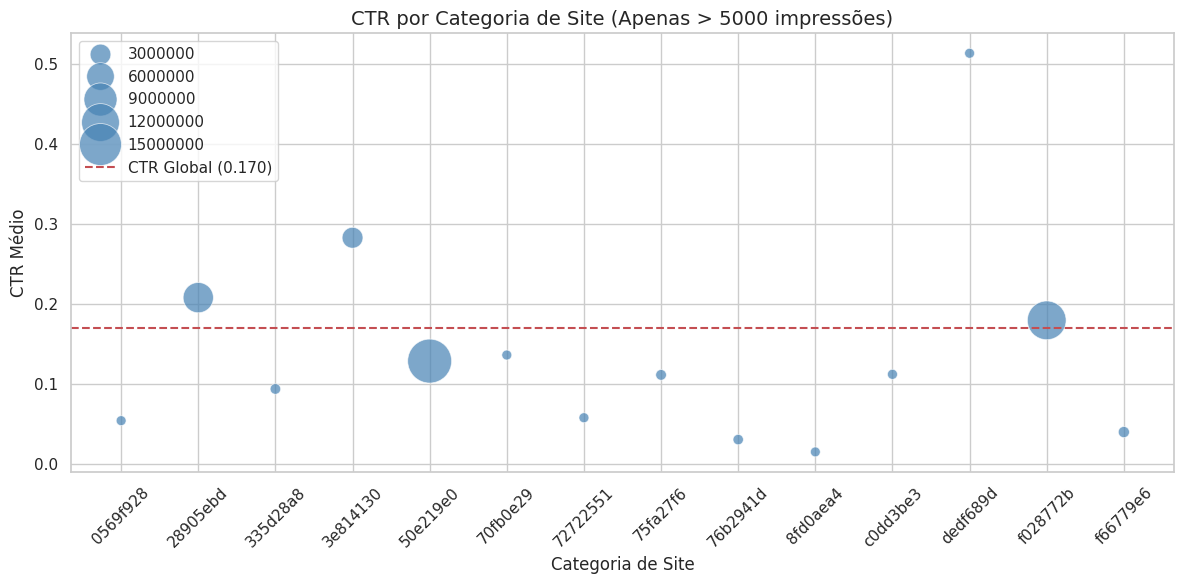

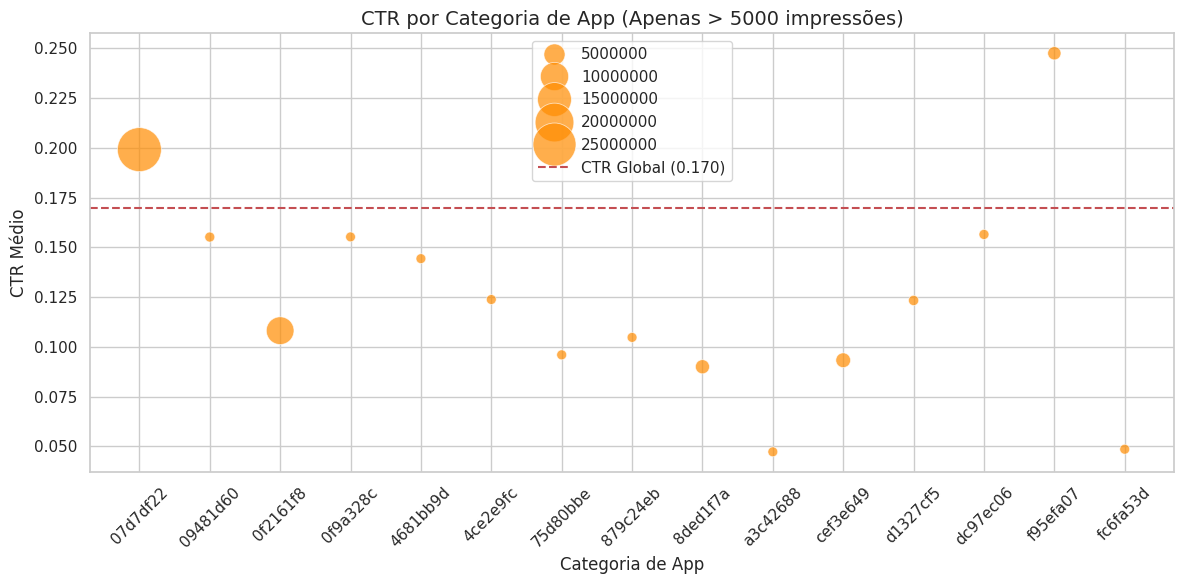

Análise bivariada de site_category e app_category concluída.


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

file_path = "/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv"
chunk_size = 1_000_000

# Acumuladores para CTR por site_category e app_category
site_cat_stats = defaultdict(lambda: {'clicks': 0, 'impressions': 0})
app_cat_stats = defaultdict(lambda: {'clicks': 0, 'impressions': 0})

print("A calcular CTR por site_category e app_category...")

for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    # CTR por site_category
    grouped_site = chunk.groupby('site_category')['click'].agg(['sum', 'count'])
    for idx, row in grouped_site.iterrows():
        site_cat_stats[idx]['clicks'] += row['sum']
        site_cat_stats[idx]['impressions'] += row['count']

    # CTR por app_category
    grouped_app = chunk.groupby('app_category')['click'].agg(['sum', 'count'])
    for idx, row in grouped_app.iterrows():
        app_cat_stats[idx]['clicks'] += row['sum']
        app_cat_stats[idx]['impressions'] += row['count']

# Preparar DataFrames
df_site = pd.DataFrame.from_dict(site_cat_stats, orient='index').reset_index()
df_site.rename(columns={'index': 'site_category'}, inplace=True)
df_site['CTR'] = df_site['clicks'] / df_site['impressions']
df_site = df_site[df_site['impressions'] > 5000]

df_app = pd.DataFrame.from_dict(app_cat_stats, orient='index').reset_index()
df_app.rename(columns={'index': 'app_category'}, inplace=True)
df_app['CTR'] = df_app['clicks'] / df_app['impressions']
df_app = df_app[df_app['impressions'] > 5000]

global_ctr = df_site['clicks'].sum() / df_site['impressions'].sum()

# --- GRÁFICO 1: CTR por site_category ---
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_site, x='site_category', y='CTR',
                size='impressions', sizes=(50, 1000),
                alpha=0.7, color='steelblue')
plt.axhline(global_ctr, color='r', linestyle='--',
            label=f'CTR Global ({global_ctr:.3f})')
plt.title("CTR por Categoria de Site (Apenas > 5000 impressões)", fontsize=14)
plt.xlabel("Categoria de Site")
plt.ylabel("CTR Médio")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# --- GRÁFICO 2: CTR por app_category ---
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_app, x='app_category', y='CTR',
                size='impressions', sizes=(50, 1000),
                alpha=0.7, color='darkorange')
plt.axhline(global_ctr, color='r', linestyle='--',
            label=f'CTR Global ({global_ctr:.3f})')
plt.title("CTR por Categoria de App (Apenas > 5000 impressões)", fontsize=14)
plt.xlabel("Categoria de App")
plt.ylabel("CTR Médio")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print("Análise bivariada de site_category e app_category concluída.")

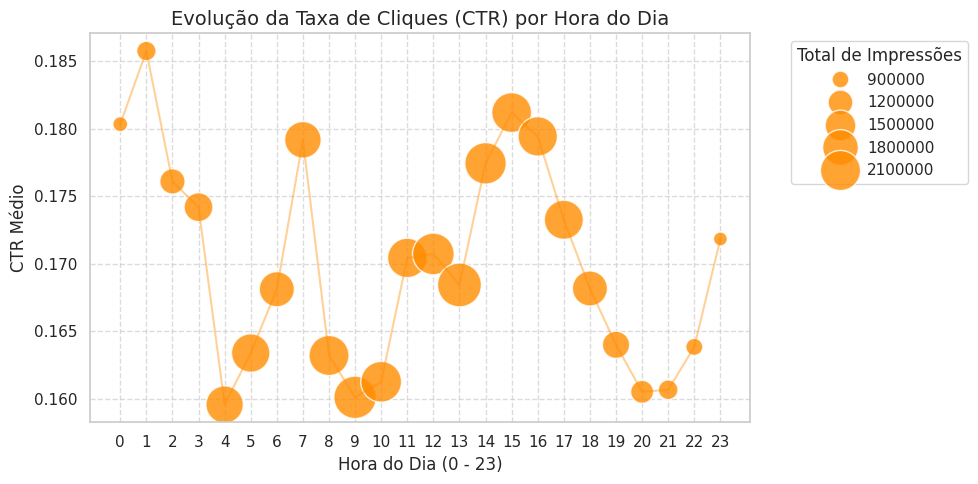

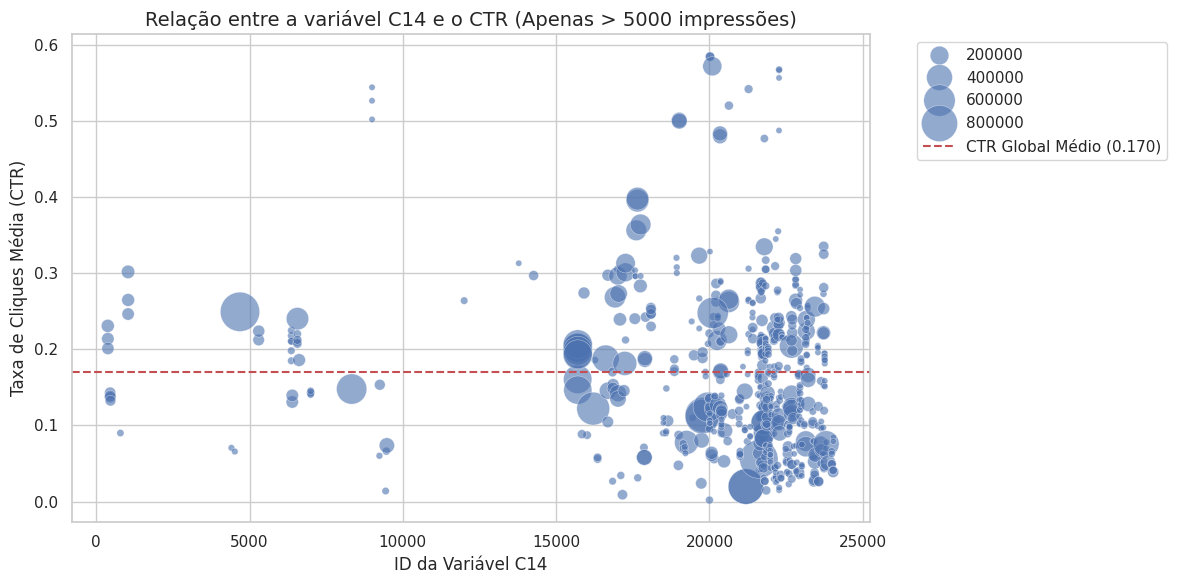

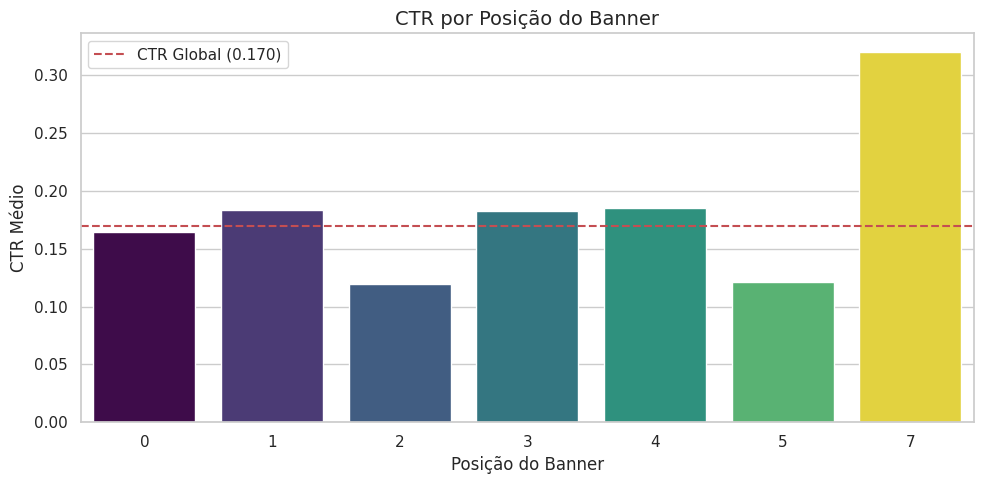

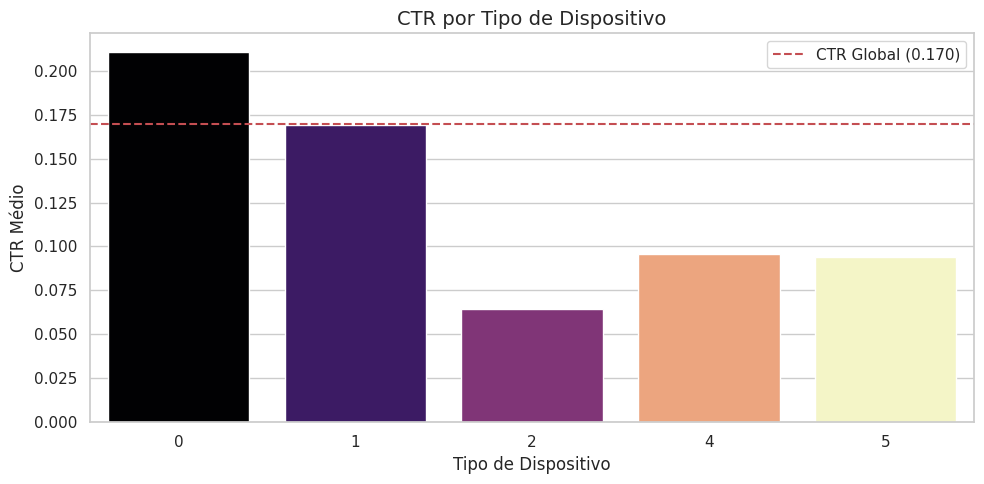

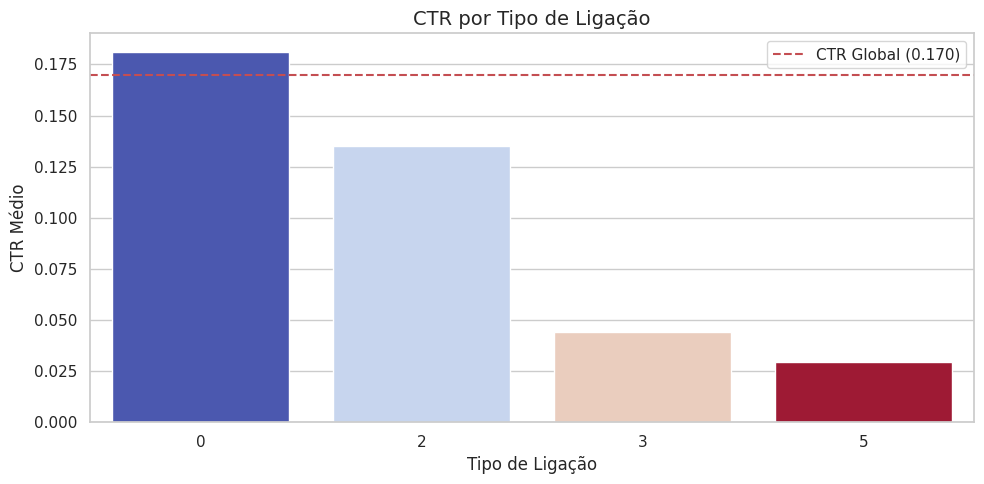

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar DataFrames com os agregados
df_hour = pd.DataFrame.from_dict(hour_stats, orient='index').reset_index()
df_hour.rename(columns={'index': 'hora_do_dia'}, inplace=True)
df_hour['CTR'] = df_hour['clicks'] / df_hour['impressions']
df_hour.sort_values('hora_do_dia', inplace=True)

df_c14 = pd.DataFrame.from_dict(c14_stats, orient='index').reset_index()
df_c14.rename(columns={'index': 'C14'}, inplace=True)
df_c14['CTR'] = df_c14['clicks'] / df_c14['impressions']

# Filtrar ruído (C14 com poucas impressões não são estatisticamente relevantes)
df_c14_filtered = df_c14[df_c14['impressions'] > 5000]
global_ctr = df_hour['clicks'].sum() / df_hour['impressions'].sum()

# --- GRÁFICO 1: CTR ao Longo do Dia ---
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_hour, x='hora_do_dia', y='CTR', size='impressions', sizes=(100, 1000), color='darkorange', alpha=0.8)
sns.lineplot(data=df_hour, x='hora_do_dia', y='CTR', color='darkorange', alpha=0.4)
plt.title("Evolução da Taxa de Cliques (CTR) por Hora do Dia", fontsize=14)
plt.xlabel("Hora do Dia (0 - 23)")
plt.ylabel("CTR Médio")
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Total de Impressões', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- GRÁFICO 2: CTR vs C14 ---
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_c14_filtered, x='C14', y='CTR', size='impressions', sizes=(20, 800), alpha=0.6, color='b')
plt.title("Relação entre a variável C14 e o CTR (Apenas > 5000 impressões)", fontsize=14)
plt.xlabel("ID da Variável C14")
plt.ylabel("Taxa de Cliques Média (CTR)")
plt.axhline(global_ctr, color='r', linestyle='--', label=f'CTR Global Médio ({global_ctr:.3f})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- GRÁFICO 3: CTR por banner_pos ---
df_banner = pd.DataFrame.from_dict(banner_stats, orient='index').reset_index()
df_banner.rename(columns={'index': 'banner_pos'}, inplace=True)
df_banner['CTR'] = df_banner['clicks'] / df_banner['impressions']

plt.figure(figsize=(10, 5))
sns.barplot(data=df_banner, x='banner_pos', y='CTR', hue='banner_pos', palette='viridis', legend=False)
plt.title("CTR por Posição do Banner", fontsize=14)
plt.xlabel("Posição do Banner")
plt.ylabel("CTR Médio")
plt.axhline(global_ctr, color='r', linestyle='--', label=f'CTR Global ({global_ctr:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

# --- GRÁFICO 4: CTR por device_type ---
df_device = pd.DataFrame.from_dict(device_type_stats, orient='index').reset_index()
df_device.rename(columns={'index': 'device_type'}, inplace=True)
df_device['CTR'] = df_device['clicks'] / df_device['impressions']

plt.figure(figsize=(10, 5))
sns.barplot(data=df_device, x='device_type', y='CTR', hue='device_type', palette='magma', legend=False)
plt.title("CTR por Tipo de Dispositivo", fontsize=14)
plt.xlabel("Tipo de Dispositivo")
plt.ylabel("CTR Médio")
plt.axhline(global_ctr, color='r', linestyle='--', label=f'CTR Global ({global_ctr:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

# --- GRÁFICO 5: CTR por device_conn_type ---
df_conn = pd.DataFrame.from_dict(device_conn_stats, orient='index').reset_index()
df_conn.rename(columns={'index': 'device_conn_type'}, inplace=True)
df_conn['CTR'] = df_conn['clicks'] / df_conn['impressions']

plt.figure(figsize=(10, 5))
sns.barplot(data=df_conn, x='device_conn_type', y='CTR', hue='device_conn_type', palette='coolwarm', legend=False)
plt.title("CTR por Tipo de Ligação", fontsize=14)
plt.xlabel("Tipo de Ligação")
plt.ylabel("CTR Médio")
plt.axhline(global_ctr, color='r', linestyle='--', label=f'CTR Global ({global_ctr:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

Esta célula converte os acumuladores calculados anteriormente em DataFrames e gera 5 gráficos de CTR para as variáveis mais relevantes

--- Temporario --- 

**Gráfico 1 — CTR por Hora do Dia:**
Mostra como o CTR varia ao longo das 24 horas, com o tamanho dos pontos proporcional ao número de impressões. Responde à pergunta de sazonalidade temporal — permite identificar os períodos do dia com maior probabilidade de clique.

**Gráfico 2 — CTR vs C14:**
Mostra a relação entre os diferentes valores da variável anónima C14 e o CTR, filtrando valores com menos de 5000 impressões para garantir relevância estatística. A linha vermelha representa o CTR global médio, permitindo identificar quais os valores de C14 que estão acima ou abaixo da média.

**Gráfico 3 — CTR por Posição do Banner:**
Mostra o CTR médio para cada posição do anúncio na página. Responde diretamente à pergunta de investigação sobre o posicionamento — permite perceber se o topo da página está de facto correlacionado com mais cliques.

**Gráfico 4 — CTR por Tipo de Dispositivo:**
Mostra como o CTR varia consoante o dispositivo usado pelo utilizador. Responde à pergunta sobre o perfil de dispositivo — permite identificar em que dispositivos os utilizadores clicam mais.

**Gráfico 5 — CTR por Tipo de Ligação:**
Mostra a influência da qualidade da ligação à internet no CTR. Complementa o gráfico anterior respondendo à pergunta sobre conectividade — permite perceber se utilizadores com melhor ligação têm maior propensão para clicar.

Feito por: Bernardo e Hugo

In [13]:
import pandas as pd
import numpy as np

# Configurações iniciais
file_path = '/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv'
chunk_size = 2_000_000 
total_rows = 0

# Dicionário para acumular a contagem de nulos de todo o dataset
null_analysis = {
    'standard_nan': None,
    'placeholder_minus_1': None,
    'placeholder_zero': None
}

print("--- Iniciando Análise de Nulos no Dataset Completo ---")

for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    # 1. Contagem de NaN padrão
    nan_count = chunk.isnull().sum()
    
    # 2. Contagem de nulos mascarados como -1
    m1_count = (chunk == -1).sum() + (chunk == '-1').sum()
    
    # 3. Contagem de nulos mascarados como 0 (comum em C20 no Avazu)
    zero_count = (chunk == 0).sum()
    
    if null_analysis['standard_nan'] is None:
        null_analysis['standard_nan'] = nan_count
        null_analysis['placeholder_minus_1'] = m1_count
        null_analysis['placeholder_zero'] = zero_count
    else:
        null_analysis['standard_nan'] += nan_count
        null_analysis['placeholder_minus_1'] += m1_count
        null_analysis['placeholder_zero'] += zero_count
        
    total_rows += len(chunk)

# Cálculo das percentagens
df_missing = pd.DataFrame({
    'Nulos_Padrao': null_analysis['standard_nan'],
    'Nulos_Mascarados(-1)': null_analysis['placeholder_minus_1'],
    'Nulos_Mascarados(0)': null_analysis['placeholder_zero']
})
df_missing['Percentagem_Total_%'] = ((df_missing['Nulos_Padrao'] + df_missing['Nulos_Mascarados(-1)'] + df_missing['Nulos_Mascarados(0)']) / total_rows) * 100

print(f"\nAnálise concluída para {total_rows} linhas.")
display(df_missing.sort_values(by='Percentagem_Total_%', ascending=False))

--- Iniciando Análise de Nulos no Dataset Completo ---

Análise concluída para 40428967 linhas.


,Nulos_Padrao,Nulos_Mascarados(-1),Nulos_Mascarados(0),Percentagem_Total_%
device_conn_type,0,0,34886838,86.291688
click,0,0,33563901,83.019438
banner_pos,0,0,29109590,72.001815
C20,0,18937918,0,46.842448
C18,0,0,16939044,41.898285
device_type,0,0,2220812,5.493121
hour,0,0,0,0.000000
id,0,0,0,0.000000
site_category,0,0,0,0.000000
site_domain,0,0,0,0.000000


=== ANTES DA LIMPEZA ===
Valores -1 em C20: 545390
Distribuição C20 (top 5):
C20
-1         545390
 100111     95626
 100084     75248
 100083     31234
 100077     27020
Name: count, dtype: int64

=== DEPOIS DA LIMPEZA ===
Valores -1 em C20: 0
Distribuição C20 (top 5):
C20
100084.0    620638
100111.0     95626
100083.0     31234
100077.0     27020
100075.0     26375
Name: count, dtype: int64



/tmp/ipykernel_17/3292641709.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_before.index.astype(str), y=counts_before.values,
/tmp/ipykernel_17/3292641709.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_after.index.astype(str), y=counts_after.values,


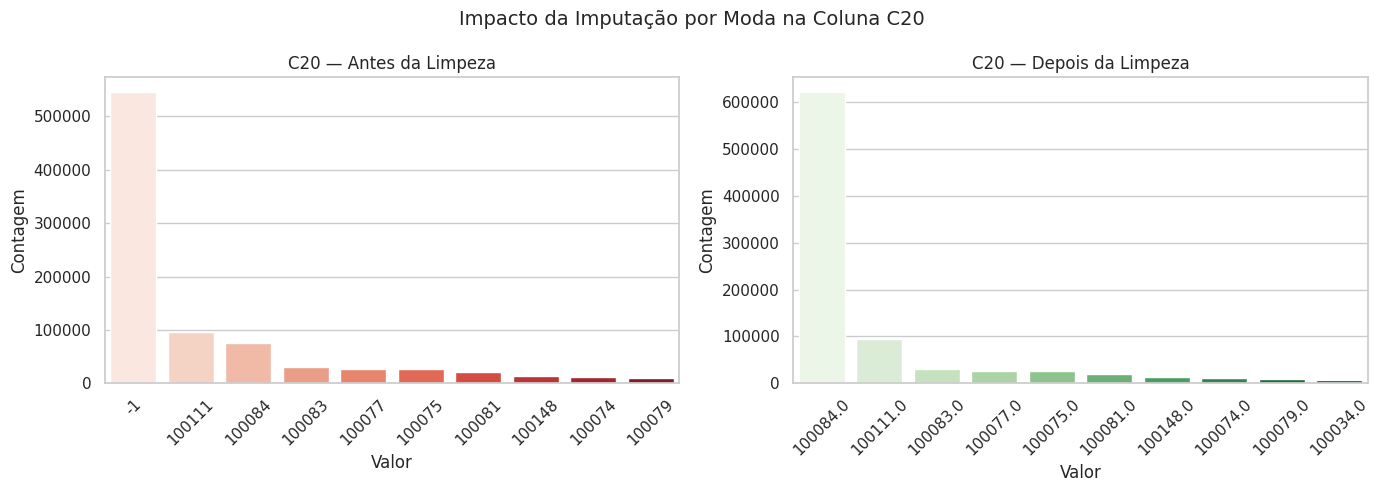

Comparação antes/depois concluída.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv"

# Carregar uma amostra para comparação visual
sample = pd.read_csv(file_path, nrows=1_000_000)

# --- ANTES DA LIMPEZA ---
print("=== ANTES DA LIMPEZA ===")
print(f"Valores -1 em C20: {(sample['C20'] == -1).sum()}")
print(f"Distribuição C20 (top 5):\n{sample['C20'].value_counts().head()}\n")

# --- APLICAR LIMPEZA ---
sample_clean = sample.copy()
moda_c20 = counts_num['C20'].drop(-1).idxmax()
sample_clean['C20'] = sample_clean['C20'].replace(-1, np.nan).fillna(moda_c20)

# --- DEPOIS DA LIMPEZA ---
print("=== DEPOIS DA LIMPEZA ===")
print(f"Valores -1 em C20: {(sample_clean['C20'] == -1).sum()}")
print(f"Distribuição C20 (top 5):\n{sample_clean['C20'].value_counts().head()}\n")

# --- VISUALIZAÇÃO COMPARATIVA ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes
counts_before = sample['C20'].value_counts().head(10)
sns.barplot(x=counts_before.index.astype(str), y=counts_before.values,
            ax=axes[0], palette='Reds')
axes[0].set_title('C20 — Antes da Limpeza')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Contagem')
axes[0].tick_params(axis='x', rotation=45)

# Depois
counts_after = sample_clean['C20'].value_counts().head(10)
sns.barplot(x=counts_after.index.astype(str), y=counts_after.values,
            ax=axes[1], palette='Greens')
axes[1].set_title('C20 — Depois da Limpeza')
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Contagem')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Impacto da Imputação por Moda na Coluna C20', fontsize=14)
plt.tight_layout()
plt.show()

del sample, sample_clean
print("Comparação antes/depois concluída.")

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

file_path = '/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv'
output_path = '/kaggle/working/train_processed.csv'
chunk_size = 2_000_000

# Colunas a remover (IDs não preditivos e multicolinearidade)
cols_to_remove = ['id', 'device_id', 'device_ip']

# Colunas categóricas para Label Encoding (alta cardinalidade)
cols_label_encoding = ['site_id', 'site_domain', 'site_category',
                       'app_id', 'app_domain', 'app_category',
                       'device_model']

# Colunas numéricas para escalonamento
cols_to_scale = ['C1', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21']

# Colunas com missing mascarado
cols_to_fix = ['C20']

# --- 1. CALCULAR MODA GLOBAL ---
print("A calcular modas globais...")
modas_globais = {}
for chunk in pd.read_csv(file_path, chunksize=chunk_size, usecols=cols_to_fix):
    for col in cols_to_fix:
        counts = chunk[col][chunk[col] != -1].value_counts()
        if col not in modas_globais:
            modas_globais[col] = counts
        else:
            modas_globais[col] = modas_globais[col].add(counts, fill_value=0)
modas_globais = {col: counts.idxmax() for col, counts in modas_globais.items()}
print(f"Modas globais: {modas_globais}")

# --- 2. VERIFICAR CORRELAÇÃO DAS NOVAS VARIÁVEIS ---
print("\nA calcular correlação incremental com todos os dados...")
stats = {
    'hora_do_dia':          {'n': 0, 'sum_x': 0, 'sum_y': 0, 'sum_xy': 0, 'sum_x2': 0, 'sum_y2': 0},
    'banner_area':          {'n': 0, 'sum_x': 0, 'sum_y': 0, 'sum_xy': 0, 'sum_x2': 0, 'sum_y2': 0},
    'visibilidade_anuncio': {'n': 0, 'sum_x': 0, 'sum_y': 0, 'sum_xy': 0, 'sum_x2': 0, 'sum_y2': 0}
}

for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    chunk['hora_do_dia'] = chunk['hour'] % 100
    chunk['banner_area'] = chunk['C15'] * chunk['C16']
    chunk['visibilidade_anuncio'] = chunk['banner_pos'] / (chunk['device_type'] + 1)

    for var in ['hora_do_dia', 'banner_area', 'visibilidade_anuncio']:
        x = chunk[var].values
        y = chunk['click'].values
        s = stats[var]
        s['n']      += len(x)
        s['sum_x']  += x.sum()
        s['sum_y']  += y.sum()
        s['sum_xy'] += (x * y).sum()
        s['sum_x2'] += (x ** 2).sum()
        s['sum_y2'] += (y ** 2).sum()

for var, s in stats.items():
    numerador = s['n'] * s['sum_xy'] - s['sum_x'] * s['sum_y']
    denominador = np.sqrt(
        (s['n'] * s['sum_x2'] - s['sum_x'] ** 2) *
        (s['n'] * s['sum_y2'] - s['sum_y'] ** 2)
    )
    corr = numerador / denominador if denominador != 0 else float('nan')
    print(f"Correlação '{var}' com 'click': {corr:.4f}")

# --- 3. PRÉ-TREINAR LABELENCODERS ---
print("\nA preparar LabelEncoders...")
categorical_counts_local = defaultdict(lambda: defaultdict(int))
for chunk in pd.read_csv(file_path, chunksize=chunk_size, usecols=cols_label_encoding):
    for col in cols_label_encoding:
        counts = chunk[col].astype(str).value_counts()
        for key, value in counts.items():
            categorical_counts_local[col][key] += value

label_encoders = {col: LabelEncoder() for col in cols_label_encoding}
for col in cols_label_encoding:
    known_values = list(categorical_counts_local[col].keys())
    label_encoders[col].fit(known_values)

# --- 4. PRÉ-CALCULAR DICIONÁRIOS DE MAPEAMENTO ---
print("A pré-calcular dicionários de mapeamento...")
mappings = {}
for col in cols_label_encoding:
    mappings[col] = dict(zip(label_encoders[col].classes_,
                             label_encoders[col].transform(label_encoders[col].classes_)))

# --- 5. PRÉ-TREINAR STANDARDSCALER ---
print("A preparar StandardScaler...")
numeric_means = defaultdict(lambda: {'n': 0, 'mean': 0.0, 'M2': 0.0})
for chunk in pd.read_csv(file_path, chunksize=chunk_size, usecols=cols_to_scale):
    for col in cols_to_scale:
        for val in chunk[col].dropna().values:
            s = numeric_means[col]
            s['n'] += 1
            delta = val - s['mean']
            s['mean'] += delta / s['n']
            s['M2'] += delta * (val - s['mean'])

scaler = StandardScaler()
scaler.mean_ = np.array([numeric_means[col]['mean'] for col in cols_to_scale])
scaler.scale_ = np.array([np.sqrt(numeric_means[col]['M2'] / numeric_means[col]['n']) for col in cols_to_scale])
scaler.n_features_in_ = len(cols_to_scale)

first_chunk = True
print("\nA processar e guardar dataset final...")

for chunk in pd.read_csv(file_path, chunksize=chunk_size):

    # --- TRATAMENTO DE OUTLIERS E ERROS ---
    for col in cols_label_encoding:
        chunk[col] = chunk[col].astype(str)

    # --- IMPUTAÇÃO DE MISSING VALUES ---
    for col in cols_to_fix:
        chunk[col] = chunk[col].replace(-1, np.nan)
        chunk[col] = chunk[col].fillna(modas_globais[col])

    # --- CRIAÇÃO DE NOVAS VARIÁVEIS ---

    # Nova variável 1: hora do dia extraída de 'hour' (formato YYMMDDHH)
    # Ex: 14102114 % 100 = 14 (14h) — permite ao modelo detetar padrões temporais de clique
    chunk['hora_do_dia'] = chunk['hour'] % 100
    
    # Nova variável 2: área do banner em píxeis (largura C15 × altura C16)
    # Um banner maior ocupa mais espaço visual e pode influenciar a probabilidade de clique
    chunk['banner_area'] = chunk['C15'] * chunk['C16']
    
    # Nova variável 3: índice de visibilidade do anúncio (posição do banner / tipo de dispositivo + 1)
    # Um banner no topo (banner_pos=0) num telemóvel (device_type=0) tem visibilidade diferente
    # do mesmo banner num PC (device_type=1) — captura a interação entre posição e dispositivo
    chunk['visibilidade_anuncio'] = chunk['banner_pos'] / (chunk['device_type'] + 1)

    # --- REMOÇÃO DE VARIÁVEIS REDUNDANTES ---
    cols_existentes = [col for col in cols_to_remove + ['hour'] if col in chunk.columns]
    chunk.drop(columns=cols_existentes, inplace=True)

    # --- LABEL ENCODING ---
    for col in cols_label_encoding:
        if col in chunk.columns:
            chunk[col] = chunk[col].map(mappings[col]).fillna(-1).astype(int)

    # --- ESCALONAMENTO ---
    cols_presentes = [col for col in cols_to_scale if col in chunk.columns]
    chunk[cols_presentes] = scaler.transform(chunk[cols_presentes])

    # --- GUARDAR DATASET PROCESSADO ---
    chunk.to_csv(output_path, mode='w' if first_chunk else 'a',
                 header=first_chunk, index=False)
    first_chunk = False

print(f"\nDataset processado guardado em: {output_path}")
print("Pipeline completo — dataset pronto para modelação.")

A calcular modas globais...
Modas globais: {'C20': np.int64(100084)}

A calcular correlação incremental com todos os dados...
Correlação 'hora_do_dia' com 'click': nan
Correlação 'banner_area' com 'click': nan
Correlação 'visibilidade_anuncio' com 'click': 0.0315

A preparar LabelEncoders...
A pré-calcular dicionários de mapeamento...
A preparar StandardScaler...

A processar e guardar dataset final...

Dataset processado guardado em: /kaggle/working/train_processed.csv
Pipeline completo — dataset pronto para modelação.


Feito por: Hugo e Bernardo

In [16]:
import pandas as pd
import numpy as np
from IPython.display import display
from collections import defaultdict

output_path = '/kaggle/working/train_processed.csv'
chunk_size = 1_000_000
total_rows_new = 0
null_counts_new = None
columns_new = None
dtypes_new = None

numeric_stats_new = defaultdict(lambda: {'n': 0, 'mean': 0.0, 'M2': 0.0, 'min': np.inf, 'max': -np.inf})
numeric_sample_new = defaultdict(list)
categorical_counts_new = defaultdict(lambda: defaultdict(int))

print("A processar dataset processado...")

for i, chunk in enumerate(pd.read_csv(output_path, chunksize=chunk_size)):

    total_rows_new += len(chunk)

    if i == 0:
        first_rows_new = chunk.head()
        columns_new = chunk.columns.tolist()
        dtypes_new = chunk.dtypes

    if null_counts_new is None:
        null_counts_new = chunk.isnull().sum()
    else:
        null_counts_new += chunk.isnull().sum()

    numeric_cols = chunk.select_dtypes(include=["int64", "float64"])
    categorical_cols = chunk.select_dtypes(include=["object"])

    for col in numeric_cols.columns:
        for val in numeric_cols[col].dropna().values:
            s = numeric_stats_new[col]
            s['n'] += 1
            delta = val - s['mean']
            s['mean'] += delta / s['n']
            s['M2'] += delta * (val - s['mean'])
            s['min'] = min(s['min'], val)
            s['max'] = max(s['max'], val)
        numeric_sample_new[col].extend(numeric_cols[col].dropna().values[::1000])

    for col in categorical_cols.columns:
        counts = categorical_cols[col].value_counts()
        for key, value in counts.items():
            categorical_counts_new[col][key] += value

print("Processamento concluído.")

# RESULTADOS GERAIS
print("DIMENSÃO")
print((total_rows_new, len(columns_new)))
print("PRIMEIRAS 5 LINHAS")
display(first_rows_new)
print("TIPOS DE DADOS")
display(dtypes_new.to_frame("Tipo"))
print("VALORES NULOS")
display(null_counts_new.to_frame("Nulos"))
print("Total de valores nulos:", int(null_counts_new.sum()))

# ESTATÍSTICAS NUMÉRICAS COMPLETAS
print("ESTATÍSTICAS NUMÉRICAS")
numeric_summary_new = {}
for col, s in numeric_stats_new.items():
    arr_sample = np.array(numeric_sample_new[col])
    std = np.sqrt(s['M2'] / s['n']) if s['n'] > 1 else 0.0
    numeric_summary_new[col] = {
        "count": s['n'],
        "mean": s['mean'],
        "std": std,
        "min": s['min'],
        "25%": np.percentile(arr_sample, 25) if len(arr_sample) > 0 else np.nan,
        "50%": np.percentile(arr_sample, 50) if len(arr_sample) > 0 else np.nan,
        "75%": np.percentile(arr_sample, 75) if len(arr_sample) > 0 else np.nan,
        "max": s['max']
    }

numeric_summary_new_df = pd.DataFrame(numeric_summary_new).T
display(numeric_summary_new_df)

# ESTATÍSTICAS CATEGÓRICAS COMPLETAS
print("ESTATÍSTICAS CATEGÓRICAS")
categorical_summary_new = {}
for col, value_dict in categorical_counts_new.items():
    total = sum(value_dict.values())
    unique = len(value_dict)
    top = max(value_dict, key=value_dict.get)
    freq = value_dict[top]
    categorical_summary_new[col] = {
        "count": total,
        "unique": unique,
        "top": top,
        "freq": freq
    }

categorical_summary_new_df = pd.DataFrame(categorical_summary_new).T
display(categorical_summary_new_df)

A processar dataset processado...
Processamento concluído.
DIMENSÃO
(40428967, 23)
PRIMEIRAS 5 LINHAS


,click,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_model,...,C15,C16,C17,C18,C19,C20,C21,hora_do_dia,banner_area,visibilidade_anuncio
0,0,0.029387,0,582,7339,2,7884,254,0,2187,...,0.052504,-0.213594,-0.640947,-1.080131,-0.547385,0.938153,-0.062346,0,16000,0.0
1,0,0.029387,0,582,7339,2,7884,254,0,3612,...,0.052504,-0.213594,-0.640947,-1.080131,-0.547385,0.938153,-0.062346,0,16000,0.0
2,0,0.029387,0,582,7339,2,7884,254,0,4460,...,0.052504,-0.213594,-0.640947,-1.080131,-0.547385,0.938153,-0.062346,0,16000,0.0
3,0,0.029387,0,582,7339,2,7884,254,0,3163,...,0.052504,-0.213594,-0.640947,-1.080131,-0.547385,0.938153,-0.062346,0,16000,0.0
4,0,0.029387,1,4695,4456,0,7884,254,0,3835,...,0.052504,-0.213594,0.079419,-1.080131,-0.547385,0.938153,1.047343,0,16000,0.5


TIPOS DE DADOS


,Tipo
click,int64
C1,float64
banner_pos,int64
site_id,int64
site_domain,int64
site_category,int64
app_id,int64
app_domain,int64
app_category,int64
device_model,int64


VALORES NULOS


,Nulos
click,0
C1,0
banner_pos,0
site_id,0
site_domain,0
site_category,0
app_id,0
app_domain,0
app_category,0
device_model,0


Total de valores nulos: 0
ESTATÍSTICAS NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
click,40428967.0,1.698056e-01,0.375462,0.000000,0.000000,0.000000,0.000000,1.000000
C1,40428967.0,-2.688407e-09,1.000000,-3.624963,0.029387,0.029387,0.029387,6.424498
banner_pos,40428967.0,2.880146e-01,0.506382,0.000000,0.000000,0.000000,1.000000,7.000000
site_id,40428967.0,2.277436e+03,1164.042611,0.000000,1705.000000,2494.000000,2494.000000,4736.000000
site_domain,40428967.0,5.189280e+03,1814.943888,0.000000,3893.000000,6000.000000,6000.000000,7744.000000
site_category,40428967.0,1.093350e+01,9.125187,0.000000,4.000000,6.000000,24.000000,25.000000
app_id,40428967.0,6.853135e+03,1993.289146,0.000000,6911.000000,7884.000000,7884.000000,8551.000000
app_domain,40428967.0,2.417329e+02,90.286379,0.000000,254.000000,254.000000,254.000000,558.000000
app_category,40428967.0,4.106325e+00,8.778540,0.000000,0.000000,0.000000,4.000000,35.000000
device_model,40428967.0,4.103961e+03,2342.852956,0.000000,1944.000000,4312.000000,6079.000000,8250.000000


ESTATÍSTICAS CATEGÓRICAS


""
